In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load datasets
customers = pd.read_csv("Customers.csv")
books = pd.read_csv("Books.csv")
orders = pd.read_csv("Orders.csv")

In [3]:
# Convert Order_Date to datetime
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'])

In [4]:
# Merge Orders with Customers and Books for analysis
df = orders.merge(customers, on='Customer_ID').merge(books, on='Book_ID')

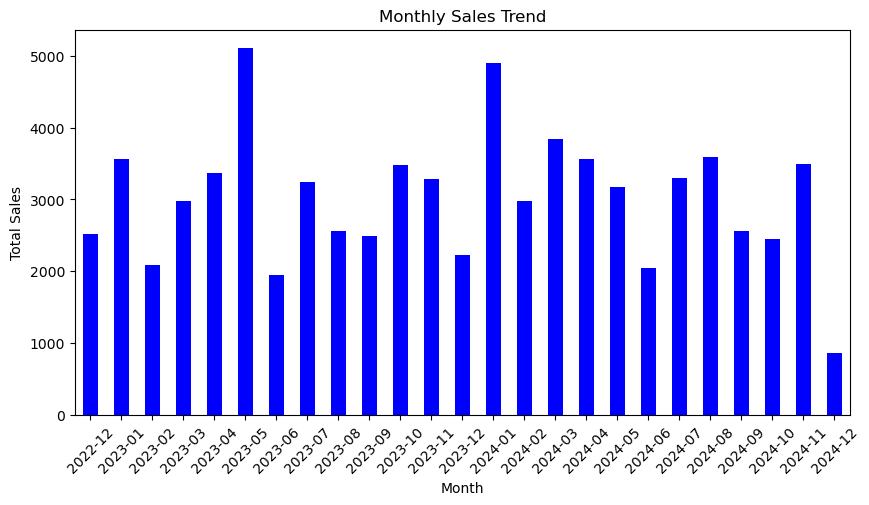

In [5]:
# Sales Trends Over Time
plt.figure(figsize=(10, 5))
df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Amount'].sum().plot(kind='bar', color='blue')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

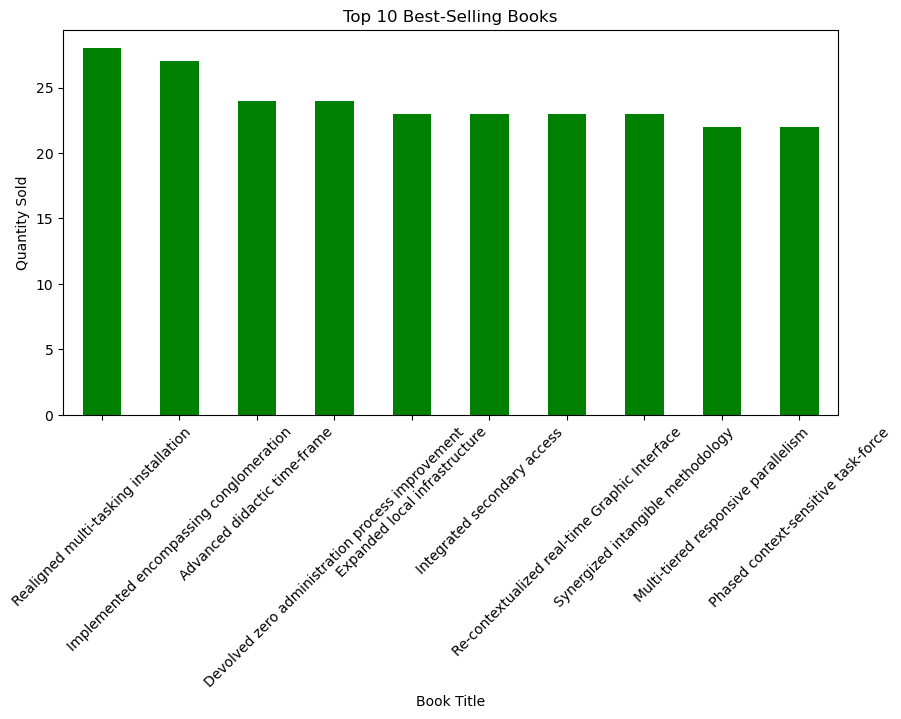

In [6]:
# Top 10 Best-Selling Books
top_books = df.groupby('Title')['Quantity'].sum().nlargest(10)
plt.figure(figsize=(10, 5))
top_books.plot(kind='bar', color='green')
plt.xlabel("Book Title")
plt.ylabel("Quantity Sold")
plt.title("Top 10 Best-Selling Books")
plt.xticks(rotation=45)
plt.show()

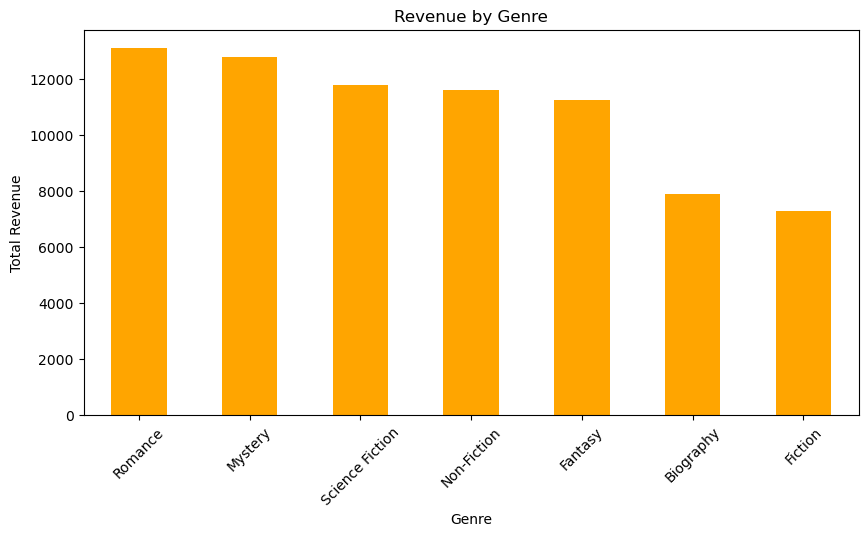

In [7]:
# Revenue by Genre
genre_revenue = df.groupby('Genre')['Total_Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
genre_revenue.plot(kind='bar', color='orange')
plt.xlabel("Genre")
plt.ylabel("Total Revenue")
plt.title("Revenue by Genre")
plt.xticks(rotation=45)
plt.show()


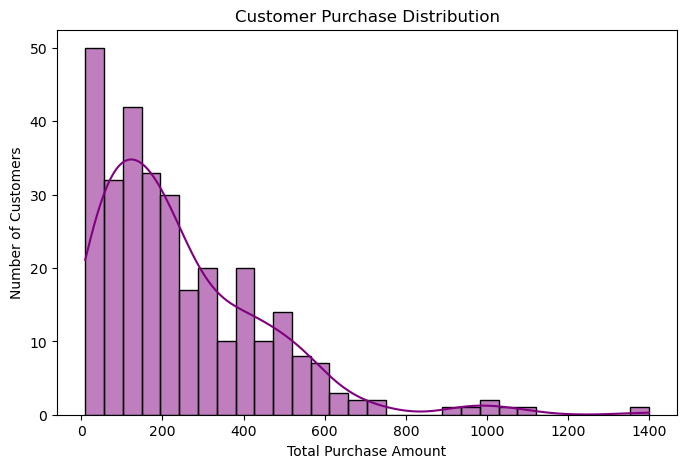

In [8]:
# Customer Purchase Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df.groupby('Customer_ID')['Total_Amount'].sum(), bins=30, kde=True, color='purple')
plt.xlabel("Total Purchase Amount")
plt.ylabel("Number of Customers")
plt.title("Customer Purchase Distribution")
plt.show()

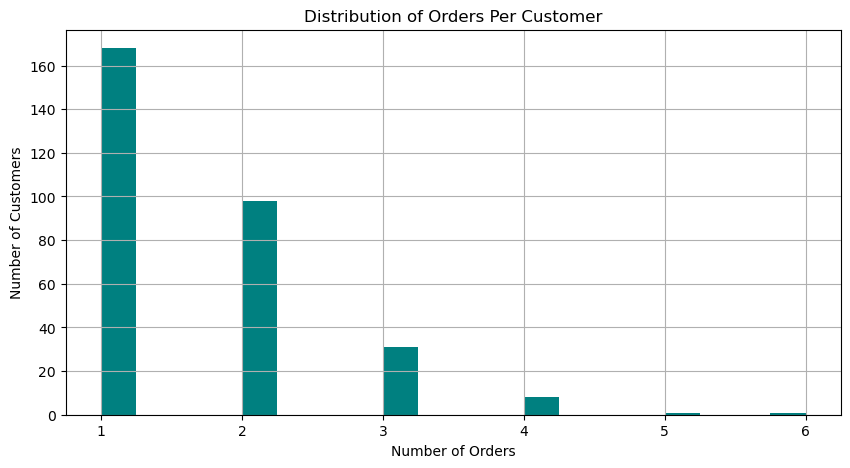

In [9]:
# Additional Analysis Scripts

# 1. Number of Orders Per Customer
customer_orders = df['Customer_ID'].value_counts()
plt.figure(figsize=(10, 5))
customer_orders.hist(bins=20, color='teal')
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Distribution of Orders Per Customer")
plt.show()

In [10]:
# 2. Average Order Value
avg_order_value = df.groupby('Order_ID')['Total_Amount'].sum().mean()
print(f"Average Order Value: {avg_order_value:.2f}")

Average Order Value: 151.26


In [11]:
# 3. Most Frequent Customers
top_customers = df.groupby('Customer_ID')['Order_ID'].count().nlargest(10)
print("Top 10 Frequent Customers:")
print(top_customers)


Top 10 Frequent Customers:
Customer_ID
364    6
474    5
107    4
174    4
325    4
405    4
425    4
437    4
457    4
485    4
Name: Order_ID, dtype: int64


In [12]:
# 4. Books with Highest Revenue
top_revenue_books = df.groupby('Title')['Total_Amount'].sum().nlargest(10)
print("Top 10 Books by Revenue:")
print(top_revenue_books)

Top 10 Books by Revenue:
Title
Integrated secondary access               1104.69
Multi-tiered responsive parallelism       1077.12
Switchable modular moratorium             1047.48
Cross-platform next generation website     952.98
Grass-roots systematic moderator           872.29
Innovative empowering concept              813.60
Assimilated composite archive              793.22
Robust tangible hardware                   764.18
Robust attitude-oriented attitude          742.50
Stand-alone content-based hub              698.60
Name: Total_Amount, dtype: float64


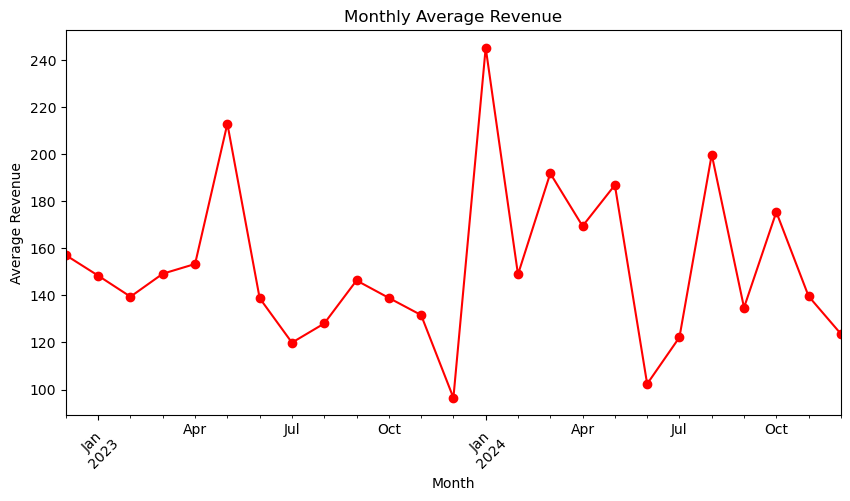

In [13]:
# 5. Monthly Average Revenue
monthly_avg_revenue = df.groupby(df['Order_Date'].dt.to_period('M'))['Total_Amount'].mean()
plt.figure(figsize=(10, 5))
monthly_avg_revenue.plot(kind='line', marker='o', color='red')
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.title("Monthly Average Revenue")
plt.xticks(rotation=45)
plt.show()

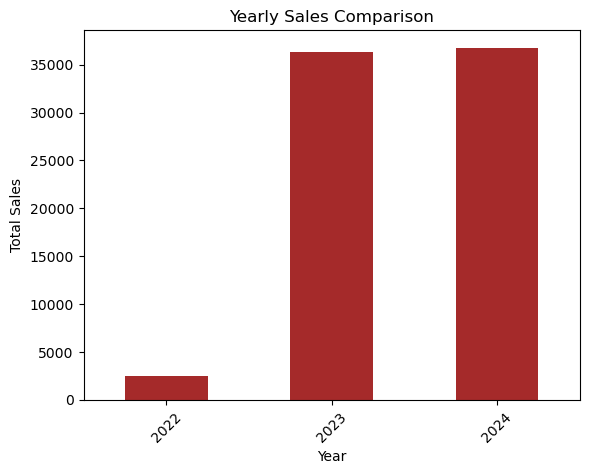

In [14]:
# 6. Yearly Sales Comparison
yearly_sales = df.groupby(df['Order_Date'].dt.year)['Total_Amount'].sum()
yearly_sales.plot(kind='bar', color='brown')
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Comparison")
plt.xticks(rotation=45)
plt.show()

In [15]:
# 7. Most Popular Authors
top_authors = df.groupby('Author')['Quantity'].sum().nlargest(10)
print("Top 10 Most Popular Authors:")
print(top_authors)

Top 10 Most Popular Authors:
Author
Patrick Contreras    28
Melissa Taylor       27
Emily James          24
Thomas Trujillo      24
Ellen Doyle          23
Erica Parker         23
Sheena Harris        23
Valerie Moore        23
Amanda Wilson        22
Rachel Gibbs         22
Name: Quantity, dtype: int64


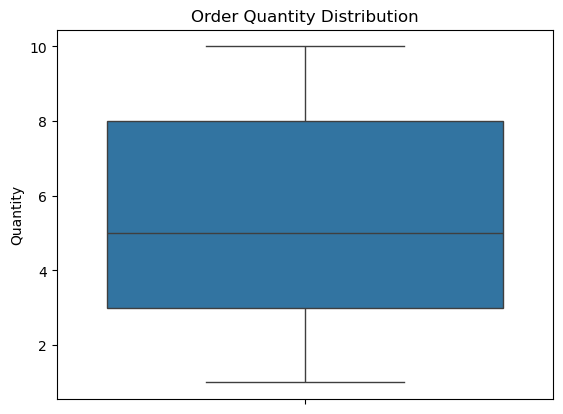

In [16]:
# 8. Order Quantity Distribution
sns.boxplot(df['Quantity'])
plt.title("Order Quantity Distribution")
plt.show()

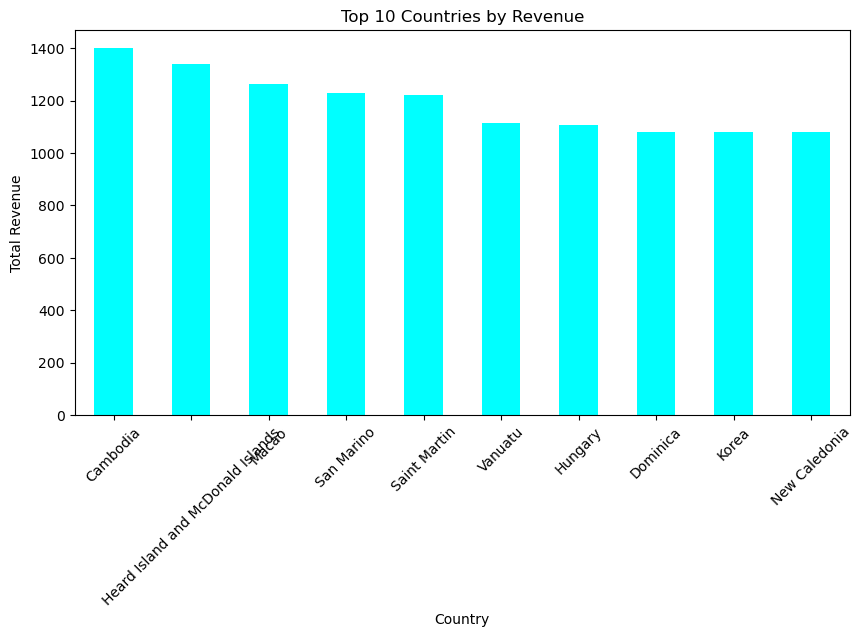

In [17]:
# 9. Revenue Distribution by Country
country_revenue = df.groupby('Country')['Total_Amount'].sum().nlargest(10)
plt.figure(figsize=(10, 5))
country_revenue.plot(kind='bar', color='cyan')
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 10 Countries by Revenue")
plt.xticks(rotation=45)
plt.show()

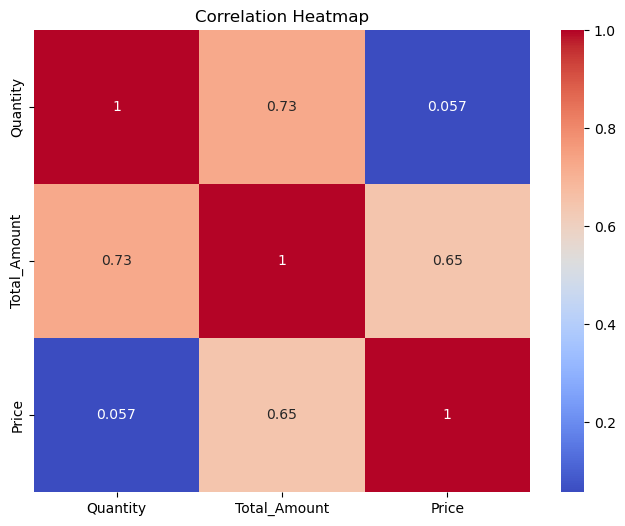

In [18]:
# 10. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Quantity', 'Total_Amount', 'Price']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# 11. Top Selling Genres
top_selling_genres = df.groupby('Genre')['Quantity'].sum().nlargest(5)
print("Top 5 Selling Genres:")
print(top_selling_genres)

Top 5 Selling Genres:
Genre
Mystery            504
Science Fiction    447
Fantasy            446
Romance            439
Non-Fiction        351
Name: Quantity, dtype: int64


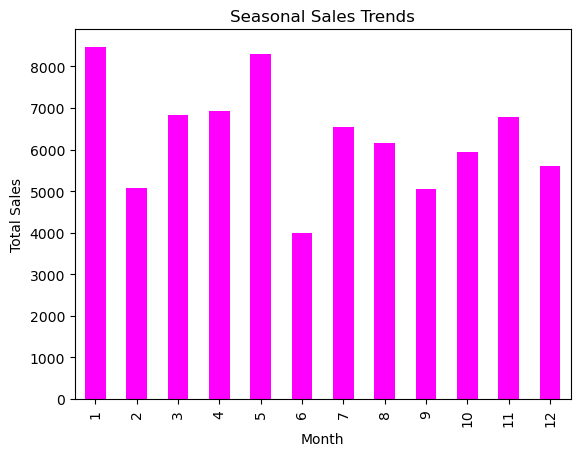

In [20]:
# 12. Seasonal Sales Trends
df['Month'] = df['Order_Date'].dt.month
seasonal_sales = df.groupby('Month')['Total_Amount'].sum()
seasonal_sales.plot(kind='bar', color='magenta')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Seasonal Sales Trends")
plt.show()

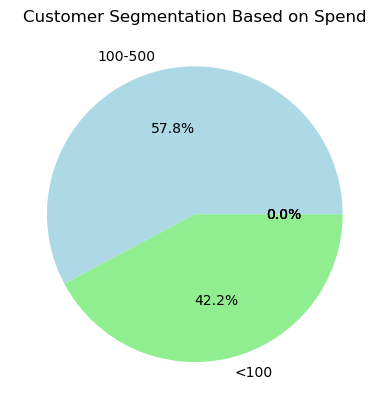

In [21]:
# 13. Customer Segmentation Based on Spend
spend_bins = [0, 100, 500, 1000, 5000, 10000]
labels = ['<100', '100-500', '500-1000', '1000-5000', '>5000']
df['Spend_Category'] = pd.cut(df['Total_Amount'], bins=spend_bins, labels=labels)
spend_category_counts = df['Spend_Category'].value_counts()
spend_category_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'pink', 'orange', 'red'])
plt.title("Customer Segmentation Based on Spend")
plt.ylabel("")
plt.show()

In [22]:
# 14. Revenue Trends by Book Age
books['Book_Age'] = 2025 - books['Published_Year']
book_age_revenue = books.groupby('Book_Age')['Price'].sum().nlargest(10)
print("Top 10 Revenue Generating Book Ages:")
print(book_age_revenue)


Top 10 Revenue Generating Book Ages:
Book_Age
118    293.93
102    257.48
4      251.96
68     244.95
35     230.10
114    226.53
38     224.37
98     220.21
112    218.69
61     208.16
Name: Price, dtype: float64


In [23]:
# 15. Top 5 High-Stock Books
high_stock_books = books.sort_values(by='Stock', ascending=False).head(5)
print("Top 5 Books with Highest Stock:")
print(high_stock_books[['Title', 'Stock']])


Top 5 Books with Highest Stock:
                                         Title  Stock
0              Configurable modular throughput    100
368             Diverse responsive focus group    100
172     Ergonomic foreground Graphic Interface    100
192      Customer-focused tertiary methodology    100
253  Team-oriented bandwidth-monitored project    100


In [24]:
# Conclusion
print("Key Insights:")
print("1. Monthly sales trends highlight peak and slow seasons.")
print("2. The most popular books and genres drive revenue.")
print("3. A small percentage of customers contribute to the majority of sales.")

Key Insights:
1. Monthly sales trends highlight peak and slow seasons.
2. The most popular books and genres drive revenue.
3. A small percentage of customers contribute to the majority of sales.
